# Buildings × UHI/Change Surfaces — Outline

**Library:** [`sitex`](../sitex) · **Original:** [`04-VIZ-BuildingsOnUHISurfaces.ipynb`](../documentations/04-VIZ-BuildingsOnUHISurfaces.ipynb)

Traces building footprints on top of each UHI/change raster (LST, NDVI, HEI, and the
NDVI/NDBI change surfaces) without hiding the surface value underneath.

This notebook used to also offer a "mask" and a "clip" mode — blanking out or
GDAL-clipping every non-building pixel, so only building-covered raster remained. Both
have been dropped: at the 30 m (Landsat) / 10 m (Sentinel-2) source resolution here,
most building footprints are smaller than a single pixel, so masking/clipping throws
away most of the raster while adding no real per-building precision — it just made the
result look sparser, not sharper. Outline is the one mode that stays useful at this
resolution.

All the logic lives in `sitex.viz.building_overlays` (+ `sitex.viz.raster_scenes` for
loading). Rendered via `sitex.core.raster_viz`, not matplotlib `imshow`/`GeoDataFrame.plot()`
— both have been confirmed to crash this project's kernel outright, independent of
what's plotted.

In [1]:
# One-time setup, if `sitex` isn't already installed in this kernel:
# %pip install "sitex[viz] @ git+https://github.com/ArchiColab/sitex.git"

import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("Running in:", "Google Colab" if IN_COLAB else "Local environment")

if IN_COLAB:
    %pip install "sitex[viz] @ git+https://github.com/ArchiColab/sitex.git"

    # Input data (read-only) — downloaded fresh each session from the workshop's GitHub release
    DATA_RELEASE_URL = "https://github.com/ArchiColab/sitex/releases/download/workshop-data-v1/Colab_Outputs.zip"
    DATA_DIR = Path("/content/Colab_Outputs")
    if not DATA_DIR.exists():
        import urllib.request, zipfile
        zip_path = Path("/content/Colab_Outputs.zip")
        urllib.request.urlretrieve(DATA_RELEASE_URL, zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DATA_DIR)

    # Your own results — saved to your own Google Drive so they persist across sessions
    from google.colab import drive
    drive.mount("/content/gdrive")
    OUTPUT_DIR = Path("/content/gdrive/MyDrive/SiteX_Outputs")
else:
    DATA_DIR = Path("..") / "data"
    OUTPUT_DIR = Path("..") / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import geopandas as gpd
from IPython.display import Image, display

from sitex.core.config import CityConfig
from sitex.core.raster_viz import save_array_png
from sitex.viz import building_overlays as bo
from sitex.viz import raster_scenes as rs

## 1. Configuration & inputs

In [2]:
city = CityConfig(
    place_name="Phường Pleiku, Gia Lai, Vietnam",
    local_lat=13.9833,
    local_lon=108.0000,
    slug="phường_pleiku",
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
)
HEI_PRIMARY = "50_50"
YEAR_EARLY, YEAR_RECENT = 2017, 2026

buildings = gpd.read_file(city.data_dir / "overture" / f"{city.slug}_buildings.gpkg").to_crs(f"EPSG:{city.local_epsg}")
print(f"{len(buildings):,} building footprints loaded — CRS: {buildings.crs}")

scene_dir = rs.find_latest_uhi_scene(city.data_dir / "landsat" / "output", HEI_PRIMARY)
uhi_layers = rs.load_uhi_layer_rasters(scene_dir, HEI_PRIMARY)
change_layers = rs.load_change_rasters(city.output_dir, YEAR_EARLY, YEAR_RECENT)
layers = {**uhi_layers, **change_layers}
print(f"Using Landsat scene: {scene_dir.name}")
for name, spec in layers.items():
    print(f"  {name:<14s} {spec['label']}")

C:\Users\Maddie\anaconda3\envs\gis\lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


21,287 building footprints loaded — CRS: EPSG:32649
Using Landsat scene: LC09_L2SP_124050_20260429_02_T1
  lst            LST (°C)
  ndvi           NDVI
  hei            HEI (0-1)
  ndvi_change    Δ NDVI (2017→2026)
  ndbi_change    Δ NDBI (2017→2026)


## 2. Preview one layer

Pick one layer with `LAYER` below (`"lst"`, `"ndvi"`, `"hei"`, `"ndvi_change"`, or
`"ndbi_change"`) to preview its building-outline overlay.

lst (LST (°C)) — building footprints traced on top


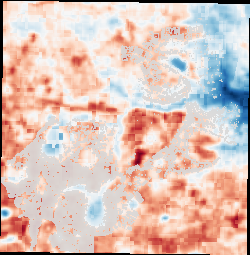

In [3]:
LAYER = "lst"
spec = layers[LAYER]

outline_rgba = bo.render_outline_overlay(spec["arr"], spec["transform"], spec["bounds"], buildings, spec["cmap"], spec["vmin"], spec["vmax"])

print(f"{LAYER} ({spec['label']}) — building footprints traced on top")

outline_png = save_array_png(outline_rgba, city.output_dir / f"buildings_{LAYER}_{city.slug}.png")
display(Image(str(outline_png)))

## 3. Export all five layers

In [4]:
for name, spec in layers.items():
    outline_rgba = bo.render_outline_overlay(spec["arr"], spec["transform"], spec["bounds"], buildings, spec["cmap"], spec["vmin"], spec["vmax"])
    save_array_png(outline_rgba, city.output_dir / f"buildings_{name}_{city.slug}.png")
    print(f"{name}: outline exported")

print(f"\nAll outputs saved to {city.output_dir}")

lst: outline exported


ndvi: outline exported


hei: outline exported


ndvi_change: outline exported


ndbi_change: outline exported

All outputs saved to ..\..\outputs


---
## Notes

- **Mask and clip modes have been dropped** — at this project's 30 m/10 m source
  resolution, most building footprints are smaller than a single pixel, so both modes
  ended up throwing away most of the raster rather than adding real per-building
  precision. Outline (footprints traced over the full, intact raster) is the mode kept.
- **The original notebooks' "publish-ready" (no title/axis, transparent background)
  export is not a separate step here** — every PNG above is already transparent where
  the raster is NaN, since `colorize_array` makes non-finite pixels transparent by
  construction. There's no separate "labelled" version with a title/colour bar baked
  into the image (those were matplotlib-only elements) — the layer name and colour
  range are printed as text instead, in Section 2 above.
- For the interactive equivalent (raster overlays + a plain building-footprint layer,
  toggleable), see `04-VIZ-Interactive_Webmap.ipynb`.